# Import Library

In [ ]:
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)

from tensorflow.keras.applications import MobileNetV3Large

# Load Folder dari Kaggle

In [ ]:
path = kagglehub.dataset_download(
    "alamshihab075/rice-leaf-disease-an-images-dataset"
)

print("Dataset berhasil di-download!")
print("Lokasi dataset:", path)

Using Colab cache for faster access to the 'rice-leaf-disease-an-images-dataset' dataset.
Dataset berhasil di-download!
Lokasi dataset: /kaggle/input/rice-leaf-disease-an-images-dataset


# Cek Folder

In [ ]:
for root, dirs, files in os.walk(path):
    print("Folder:", root)
    print("Subfolder:", dirs)
    break

Folder: /kaggle/input/rice-leaf-disease-an-images-dataset
Subfolder: ['Rice Disease']


# Load Dataset

In [ ]:
DATASET_DIR = os.path.join(path, "Rice Disease")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print(DATASET_DIR)
print(os.listdir(DATASET_DIR))

/kaggle/input/rice-leaf-disease-an-images-dataset/Rice Disease
['Leaf Scald', 'Tungro', 'Hispa', 'Sheath Blight', 'False Smut', 'Bacterial Blight', 'Ragged Stunt Virus', 'Narrow Brown Spot', 'Healthy', 'Leaf Blast', 'Stem Rot', 'Bacterial Streak', 'Bakanae', 'Neck Blast', 'Sheath Rot', 'Brown Spot', 'Leaf Smut', 'Grassy Stunt Virus']


Dataset terdiri dari 18 kelas citra daun padi yang mencakup berbagai jenis penyakit seperti bakteri, jamur, virus, serta kondisi tanaman sehat.

# Eksplorasi Dataset Analysis

Leaf Scald: 2608
Tungro: 3228
Hispa: 2209
Sheath Blight: 632
False Smut: 149
Bacterial Blight: 4248
Ragged Stunt Virus: 100
Narrow Brown Spot: 1808
Healthy: 2952
Leaf Blast: 3456
Stem Rot: 100
Bacterial Streak: 99
Bakanae: 100
Neck Blast: 1322
Sheath Rot: 91
Brown Spot: 4661
Leaf Smut: 1500
Grassy Stunt Virus: 100


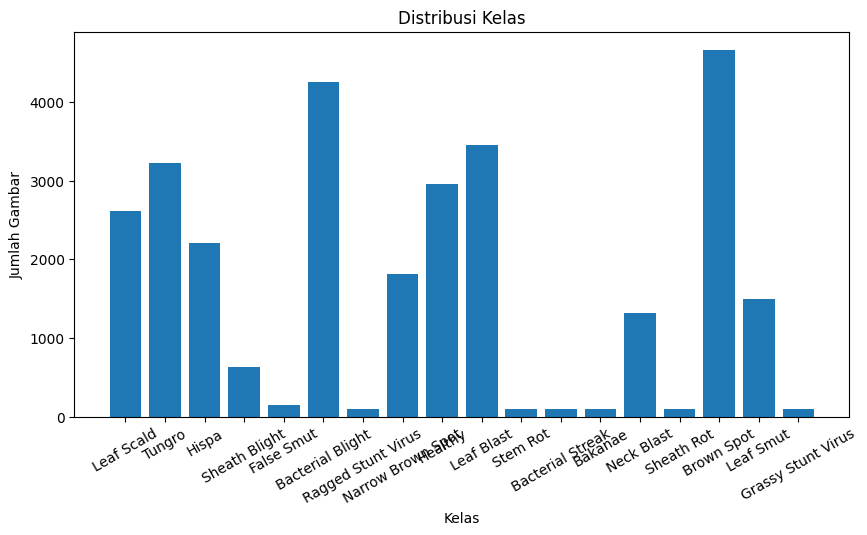

In [ ]:
class_counts = {}

for cls in os.listdir(DATASET_DIR):

    cls_path = os.path.join(DATASET_DIR, cls)

    if os.path.isdir(cls_path):

        count = len(os.listdir(cls_path))
        class_counts[cls] = count

        print(f"{cls}: {count}")

plt.figure(figsize=(10,5))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.title("Distribusi Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")

plt.xticks(rotation=30)

plt.show()

Hasil menunjukkan bahwa dataset terdiri dari 18 kelas penyakit daun padi dengan distribusi yang sangat tidak seimbang (imbalanced dataset).

## Sampel Citra

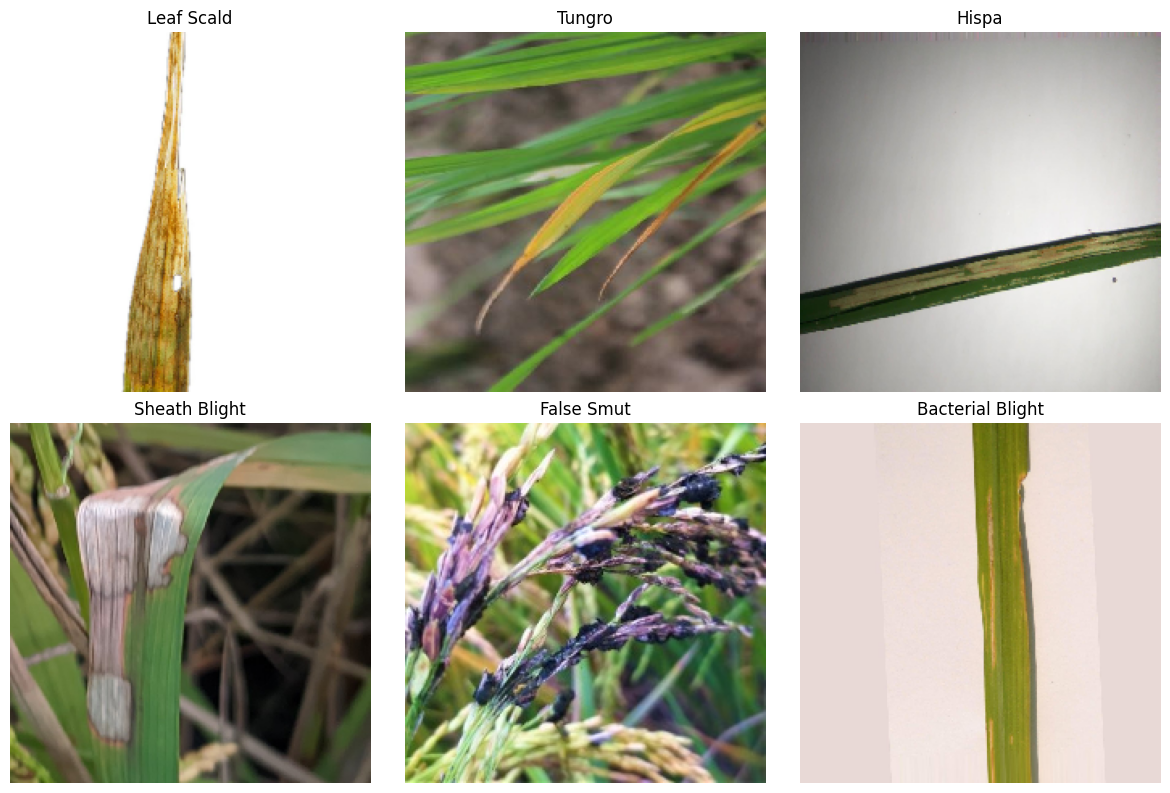

In [ ]:
classes = os.listdir(DATASET_DIR)

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes[:6]):

    img_name = os.listdir(os.path.join(DATASET_DIR, cls))[0]

    img_path = os.path.join(DATASET_DIR, cls, img_name)

    img = load_img(img_path, target_size=IMG_SIZE)

    plt.subplot(2,3,i+1)

    plt.imshow(img)
    plt.title(cls)

    plt.axis("off")

plt.tight_layout()
plt.show()

# Preprocessing dan Augmentasi Data

In [ ]:
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    shear_range=0.1,
    brightness_range=[0.8,1.2],
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training'
)

val_gen = test_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())

print(class_names)

Found 23497 images belonging to 18 classes.
Found 5866 images belonging to 18 classes.
['Bacterial Blight', 'Bacterial Streak', 'Bakanae', 'Brown Spot', 'False Smut', 'Grassy Stunt Virus', 'Healthy', 'Hispa', 'Leaf Blast', 'Leaf Scald', 'Leaf Smut', 'Narrow Brown Spot', 'Neck Blast', 'Ragged Stunt Virus', 'Sheath Blight', 'Sheath Rot', 'Stem Rot', 'Tungro']


# Ekstraksi Fitur (MobileNetV3)

In [ ]:
base_model = MobileNetV3Large(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

base_model.trainable = False

print("MobileNetV3 Loaded")

MobileNetV3 Loaded


In [ ]:
def extract_features(generator):

    features = []
    labels = []

    for imgs, lbls in generator:

        feat = base_model.predict(imgs, verbose=0)

        features.append(feat)
        labels.append(lbls)

        if len(features) >= len(generator):
            break

    X = np.vstack(features)
    y = np.concatenate(labels)

    return X, y

print("Extract Train Features...")
X_train, y_train = extract_features(train_gen)

print("Extract Validation Features...")
X_test, y_test = extract_features(val_gen)

print(X_train.shape)
print(X_test.shape)

Extract Train Features...
Extract Validation Features...
(23497, 960)
(5866, 960)


Hasil ekstraksi fitur menggunakan MobileNetV3 menghasilkan representasi citra berdimensi 960 fitur untuk setiap sampel. Dataset terdiri dari 23.497 data training dan 5.866 data validasi.

# Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

print("Training selesai")

Training selesai


# Evalusasi Model

In [ ]:
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='macro'
)

recall = recall_score(
    y_test,
    y_pred,
    average='macro'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)

print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("Macro F1 :", f1)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

Accuracy : 0.6815547221275144
Precision: 0.7638210651676167
Recall   : 0.5600483837194513
Macro F1 : 0.5779772330830505

Classification Report:

                    precision    recall  f1-score   support

  Bacterial Blight       0.67      0.97      0.79       849
  Bacterial Streak       0.75      0.32      0.44        19
           Bakanae       0.90      0.45      0.60        20
        Brown Spot       0.69      0.96      0.80       932
        False Smut       1.00      1.00      1.00        29
Grassy Stunt Virus       1.00      0.90      0.95        20
           Healthy       0.50      0.64      0.56       590
             Hispa       0.01      0.00      0.00       441
        Leaf Blast       0.44      0.40      0.42       691
        Leaf Scald       0.65      0.13      0.22       521
         Leaf Smut       0.76      0.96      0.85       300
 Narrow Brown Spot       0.99      0.81      0.89       361
        Neck Blast       0.99      1.00      0.99       264
Ragged Stunt V

Hasil evaluasi menunjukkan bahwa model mencapai akurasi sebesar 67.8% dengan macro F1-score sebesar 0.566. Meskipun precision tergolong tinggi, nilai recall yang lebih rendah menunjukkan bahwa model belum mampu mengenali seluruh kelas secara merata. Hal ini disebabkan oleh ketidakseimbangan distribusi data serta kemiripan karakteristik antar kelas penyakit daun padi.

## Confusion Matrix

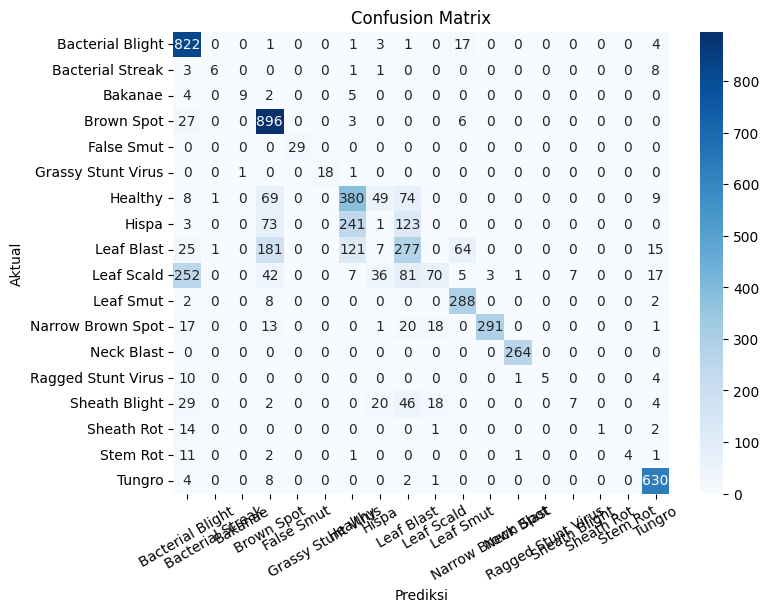

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.xticks(rotation=30)

plt.show()